In [1]:
# DAY 23 - FEATURE SELECTION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the cleaned Sales dataset

df = pd.read_csv("../cleaned_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (51290, 23)


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,shipping_days,profit_margin
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011,5,26.014706
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011,7,30.030000
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011,4,44.909091
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011,4,-57.900000
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011,7,33.131579


In [3]:
# Check all columns in the dataset

print("Dataset columns:")
print(df.columns.tolist())

Dataset columns:
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'shipping_days', 'profit_margin']


In [4]:
# Select numerical columns for feature selection

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numerical columns:")
print(list(numerical_columns))

Numerical columns:
['sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'year', 'shipping_days', 'profit_margin']


In [5]:
# Calculate correlations between numerical features

correlation_matrix = df[numerical_columns].corr()

print("Correlation matrix:")
print(correlation_matrix)

Correlation matrix:
                  sales  quantity  discount    profit  shipping_cost  \
sales          1.000000  0.313580 -0.086728  0.485944       0.768075   
quantity       0.313580  1.000000 -0.019875  0.104743       0.272649   
discount      -0.086728 -0.019875  1.000000 -0.316375      -0.079056   
profit         0.485944  0.104743 -0.316375  1.000000       0.357033   
shipping_cost  0.768075  0.272649 -0.079056  0.357033       1.000000   
year          -0.002902 -0.005049 -0.005894  0.002661      -0.003136   
shipping_days -0.004661  0.004347 -0.001507  0.001543      -0.142823   
profit_margin  0.074710  0.050487 -0.846445  0.357199       0.067945   

                   year  shipping_days  profit_margin  
sales         -0.002902      -0.004661       0.074710  
quantity      -0.005049       0.004347       0.050487  
discount      -0.005894      -0.001507      -0.846445  
profit         0.002661       0.001543       0.357199  
shipping_cost -0.003136      -0.142823       0.0679

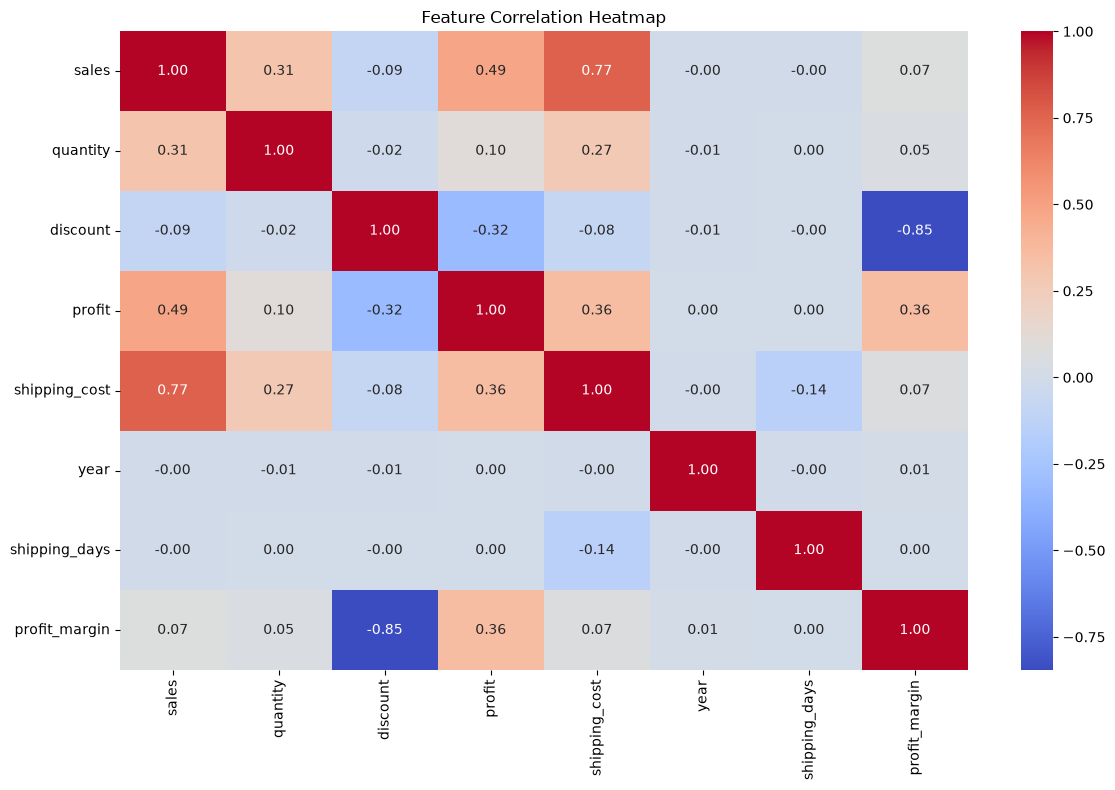

In [6]:
# Visualize feature correlations

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()

plt.show()

In [7]:
# Create target variable

y = (df["profit"] > 0).astype(int)

print("Target created successfully!")
print("\nTarget distribution:")
print(y.value_counts())

Target created successfully!

Target distribution:
profit
1    38079
0    13211
Name: count, dtype: int64


In [8]:
# Prepare numerical features for the model

feature_columns = [
    "sales",
    "quantity",
    "discount",
    "shipping_cost",
    "shipping_days"
]

X = df[feature_columns].astype(float)

print("Features prepared successfully!")
print("\nSelected features:")
print(feature_columns)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features prepared successfully!

Selected features:
['sales', 'quantity', 'discount', 'shipping_cost', 'shipping_days']

X shape: (51290, 5)
y shape: (51290,)


In [9]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data split successfully!")
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Data split successfully!
Training data: (41032, 5)
Testing data: (10258, 5)


In [10]:
# Train baseline Logistic Regression model

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully!")

Baseline model trained successfully!


In [11]:
# Evaluate baseline model

baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

print("Baseline Accuracy:", round(baseline_accuracy, 3))

Baseline Accuracy: 0.92


In [12]:
# Calculate feature importance from Logistic Regression coefficients

feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": np.abs(baseline_model.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature importance:")
print(feature_importance)

Feature importance:
         Feature  Importance
2       discount   13.147553
1       quantity    0.022022
4  shipping_days    0.005064
3  shipping_cost    0.000590
0          sales    0.000180


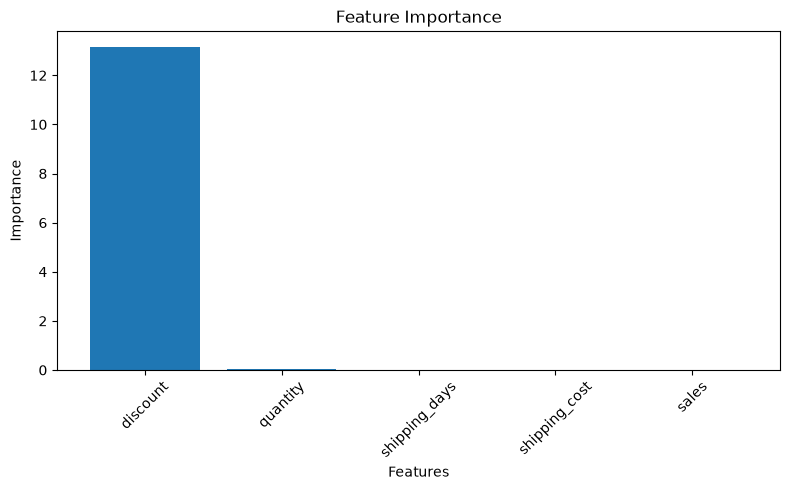

In [13]:
# Visualize feature importance

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [14]:
# Select important features

importance_threshold = feature_importance["Importance"].mean()

selected_features = feature_importance[
    feature_importance["Importance"] >= importance_threshold
]["Feature"].tolist()

print("Importance threshold:", round(importance_threshold, 4))

print("\nSelected features:")
print(selected_features)

print("\nNumber of selected features:", len(selected_features))

Importance threshold: 2.6351

Selected features:
['discount']

Number of selected features: 1


In [15]:
# Create dataset using selected features only

X_selected = X[selected_features]

print("Selected-feature dataset created!")
print("\nSelected features:")
print(selected_features)

print("\nSelected dataset shape:", X_selected.shape)

Selected-feature dataset created!

Selected features:
['discount']

Selected dataset shape: (51290, 1)


In [16]:
# Split selected features into training and testing sets

X_selected_train, X_selected_test, y_selected_train, y_selected_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Selected-feature data split successfully!")
print("Training data:", X_selected_train.shape)
print("Testing data:", X_selected_test.shape)

Selected-feature data split successfully!
Training data: (41032, 1)
Testing data: (10258, 1)


In [17]:
# Train Logistic Regression using selected features

selected_model = LogisticRegression(max_iter=1000)

selected_model.fit(
    X_selected_train,
    y_selected_train
)

print("Selected-feature model trained successfully!")

Selected-feature model trained successfully!


In [18]:
# Evaluate model after feature selection

selected_pred = selected_model.predict(X_selected_test)

selected_accuracy = accuracy_score(
    y_selected_test,
    selected_pred
)

print("Accuracy After Feature Selection:", round(selected_accuracy, 3))

Accuracy After Feature Selection: 0.921


In [19]:
# Compare model performance before and after feature selection

comparison_df = pd.DataFrame({
    "Model": [
        "Before Feature Selection",
        "After Feature Selection"
    ],
    "Accuracy": [
        baseline_accuracy,
        selected_accuracy
    ]
})

print(comparison_df)

                      Model  Accuracy
0  Before Feature Selection  0.920062
1   After Feature Selection  0.920745


In [20]:
# Save the performance comparison report

comparison_df.to_csv(
    "feature_selection_comparison.csv",
    index=False
)

print("Comparison report saved successfully!")
print("File: feature_selection_comparison.csv")

Comparison report saved successfully!
File: feature_selection_comparison.csv


In [21]:
# Save feature importance results

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")
print("File: feature_importance.csv")

Feature importance saved successfully!
File: feature_importance.csv


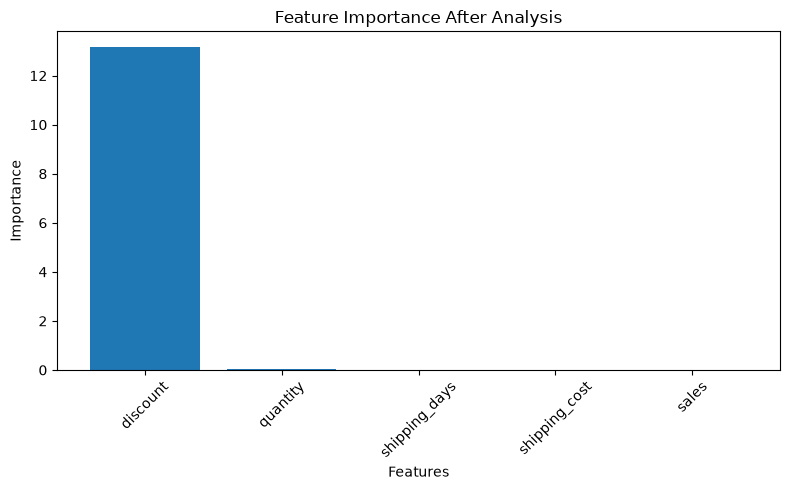

Feature importance graph saved successfully!


In [22]:
# Save the feature importance visualization

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance After Analysis")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Feature importance graph saved successfully!")

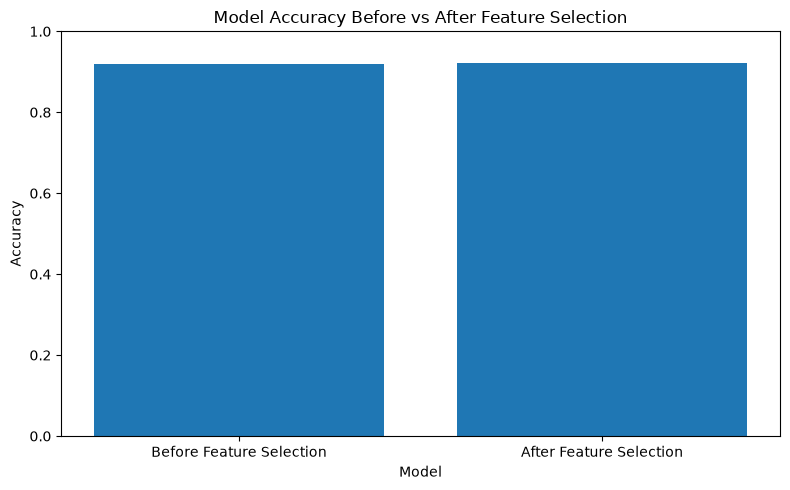

In [23]:
# Visualize model performance before and after feature selection

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Model Accuracy Before vs After Feature Selection")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.tight_layout()

plt.show()

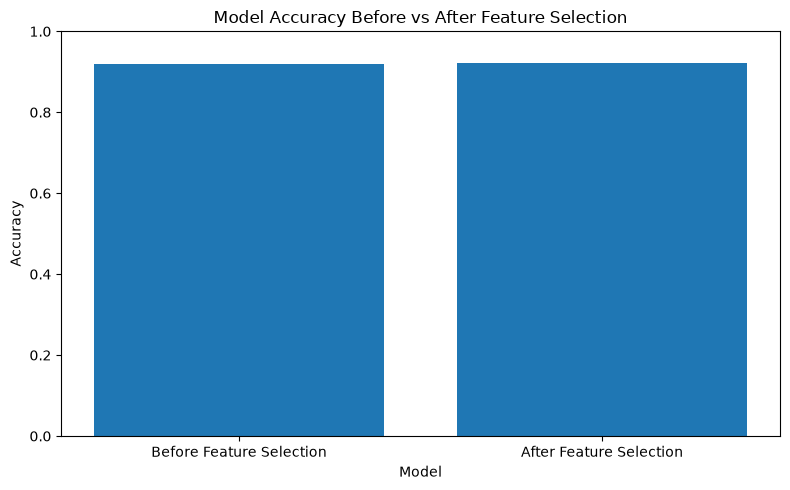

Comparison graph saved successfully!


In [24]:
# Save the model performance comparison graph

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Model Accuracy Before vs After Feature Selection")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    "feature_selection_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Comparison graph saved successfully!")

In [25]:
# Final Day 23 file check

import os

files = [
    "feature_importance.csv",
    "feature_selection_comparison.csv",
    "feature_importance.png",
    "feature_selection_comparison.png"
]

print("Day 23 files:")

for file in files:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌", file)
        

Day 23 files:
✅ feature_importance.csv
✅ feature_selection_comparison.csv
✅ feature_importance.png
✅ feature_selection_comparison.png
